In [27]:
import os
import tarfile
from urllib.request import urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from PIL import Image


In [34]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5vTzHBmQUaRNJQe5szCyKw/images-dataSAT.tar"
extraction_path = "."
archive_path = os.path.join(extraction_path, os.path.basename(url))

urlretrieve(url, archive_path)

with tarfile.open(archive_path, "r") as archive:
    archive.extractall(path=extraction_path)

print(f"Files extracted to: {extraction_path}")


Files extracted to: .


## Set the dataset folders

- `dir_non_agri`: non-agricultural images.
- `dir_agri`: agricultural images.

**Why:** These paths tell Python where each image class is stored.

In [2]:
dir_non_agri = "images_dataSAT/class_0_non_agri"
dir_agri = "images_dataSAT/class_1_agri"

## Collect image paths

In [29]:
non_agri_paths = sorted(
    os.path.join(dir_non_agri, filename)
    for filename in os.listdir(dir_non_agri)
)


## Display one image

In [4]:
image = Image.open(non_agri_paths[0])
plt.imshow(image)
plt.show()

## Display the first four images

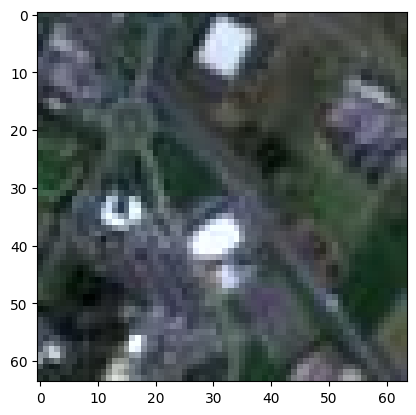

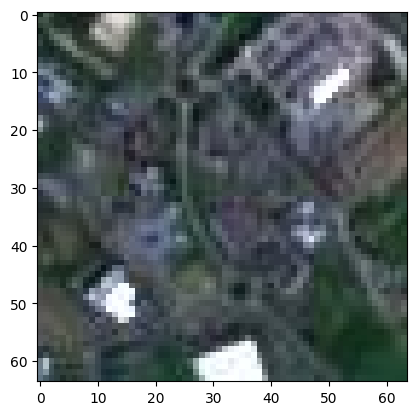

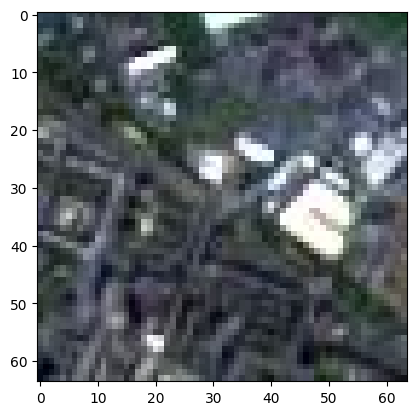

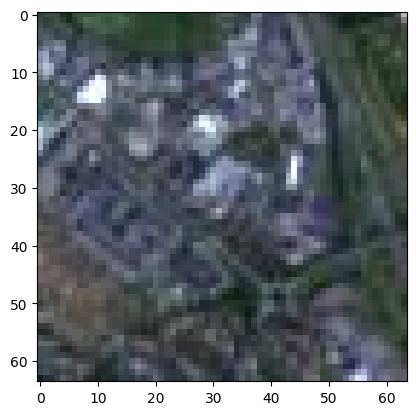

In [6]:
for path in non_agri_paths[:4]:
    plt.imshow(Image.open(path))
    plt.show()

In [7]:
print(len(non_agri_paths))

3000


## Why use paths instead of loading every image?

A path-based workflow keeps only the current batch in memory:

```text
Image path -> open one batch -> train -> open the next batch
```

Loading every image at once can use much more RAM. Keeping paths first is more memory-efficient and is the main idea demonstrated by this exercise.


## Define the image folders

- `base_dir`: the main dataset directory.
- `dir_non_agri`: the non-agricultural image directory.
- `dir_agri`: the agricultural image directory.

**Why:** Centralizing these paths makes the rest of the notebook easier to read and update.


In [8]:
base_dir = "./images_dataSAT"

dir_non_agri = base_dir + "/class_0_non_agri"
dir_agri = base_dir + "/class_1_agri"

## Create image paths and labels

Each image path is paired with its class label:

| Folder | Label |
| --- | ---: |
| `class_0_non_agri` | 0 |
| `class_1_agri` | 1 |

**Why:** Supervised learning requires both an input image and the correct answer for that image.


In [30]:
all_image_paths = []
all_labels = []

for filename in sorted(os.listdir(dir_non_agri)):
    all_image_paths.append(os.path.join(dir_non_agri, filename))
    all_labels.append(0)

for filename in sorted(os.listdir(dir_agri)):
    all_image_paths.append(os.path.join(dir_agri, filename))
    all_labels.append(1)


## Shuffle paths and labels together

`zip()` creates pairs such as `(image_path, label)`. Shuffling the pairs changes their order while keeping every image matched to its correct label.

**Why:** A mixed order prevents the model from seeing all images of one class before all images of the other class.


In [10]:
data = list(zip(all_image_paths, all_labels))
np.random.shuffle(data)

all_image_paths, all_labels = zip(*data)

## Create a batch generator

The generator opens and processes a small batch only when the model requests it. This avoids loading the entire image collection into memory at once.

```text
paths -> load a batch -> train -> load the next batch
```


In [12]:
def generator(paths, labels, batch_size=8):

    while True:
        images = []
        batch_labels = []

        for path, label in zip(paths, labels):
            img = tf.keras.utils.load_img(path, target_size=(64, 64))
            img = tf.keras.utils.img_to_array(img)

            images.append(img)
            batch_labels.append(label)

            if len(images) == batch_size:
                yield np.array(images) / 255.0, np.array(batch_labels)
                images = []
                batch_labels = []

In [14]:
import tensorflow as tf

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [28]:
batch_size = 8

data_generator = generator(
    all_image_paths,
    all_labels,
    batch_size=batch_size,
)

images, labels = next(data_generator)


In [16]:
print(images.shape)
print(labels.shape)

(8, 64, 64, 3)
(8,)


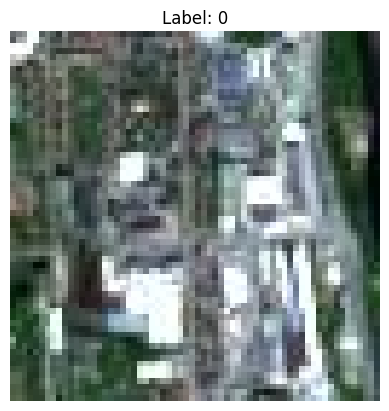

In [31]:
sample_index = 0

plt.imshow(images[sample_index])
plt.title(f"Label: {int(labels[sample_index])}")
plt.axis("off")
plt.show()


## Use Keras for directory-based loading

Keras can infer class labels from folder names and create batched datasets for us. This is simpler and less error-prone than maintaining a custom generator.

In [32]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,  # Infer classes from the subfolder names.
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=(64, 64),
    batch_size=8,
)


Found 6000 files belonging to 2 classes.
Using 4800 files for training.


In [33]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels="inferred",
    label_mode="int",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=(64, 64),
    batch_size=8,
)


Found 6000 files belonging to 2 classes.
Using 1200 files for validation.


## Augment the training images

```text
Original image -> flipped or rotated image
```

Augmentation creates additional variations so the CNN can learn patterns that are less sensitive to orientation.


In [24]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
])

## Apply augmentation to training batches

The images are randomly flipped or rotated while their labels stay unchanged.

**Why:** These transformations create realistic variation without changing whether an image is agricultural or non-agricultural.


In [25]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

## Cache the processed training data

Caching keeps processed batches available for later epochs, reducing repeated disk reads.

**Why:** This can speed up training when the dataset fits comfortably in memory. For large datasets, omit caching to avoid excessive RAM usage.


In [26]:
train_ds = train_ds.cache()

Let TensorFlow decide a suitable setting automatically.

You don't have to manually choose the prefetch buffer size.

In [36]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

| Library      | Purpose                                               |
| ------------ | ----------------------------------------------------- |
| `os`         | Work with folders and file paths                      |
| `numpy`      | Handle arrays and shuffle data                        |
| `matplotlib` | Display images                                        |
| `PIL.Image`  | Open images                                           |
| `torch`      | PyTorch deep learning                                 |
| `Dataset`    | Create a custom dataset                               |
| `DataLoader` | Create batches of images                              |
| `datasets`   | Use PyTorch's built-in datasets such as `ImageFolder` |
| `transforms` | Resize, flip, rotate, normalize images                |


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Define the directories


In [2]:
base_dir = os.path.join(".", "images_dataSAT")

dir_non_agri = os.path.join(base_dir, "class_0_non_agri")
dir_agri = os.path.join(base_dir, "class_1_agri")

dir_non_agri = base_dir + "/class_0_non_agri"
dir_agri = base_dir + "/class_1_agri"

## Custom PyTorch `Dataset`

In PyTorch, 
- A `Dataset` object is an iterable (gives one sample at a time).

- A `DataLoader` is an iterator that returns batches (adds a batch dimension: `[B, C, H, W]`).

- To create a custom dataset, we will create a class that inherits from `torch.utils.data.Dataset` and implements three essential methods:
- `__init__(self)`: This method is run once when the dataset is instantiated. It's where you perform initial setup, such as loading file paths and labels.
- `__len__(self)`: This returns the total number of samples in the dataset.
- `__getitem__(self, idx)`: This method is responsible for loading and returning a *single* sample from the dataset at the given index `idx`. This is the core of sequential loading; it fetches one data point from storage "just-in-time".


In [3]:
class CustomDataset(Dataset):

    def __init__(self, non_agri_dir, agri_dir, transform=None):
        self.transform = transform
        self.images = []
        self.labels = []

        for file in os.listdir(non_agri_dir):
            self.images.append(os.path.join(non_agri_dir, file))
            self.labels.append(0)

        for file in os.listdir(agri_dir):
            self.images.append(os.path.join(agri_dir, file))
            self.labels.append(1)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = Image.open(self.images[index]).convert("RGB")
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

### Define transformations

- `torchvision.transforms` provides a suite of common image transformations. These are used for preprocessing (such as `resizing` and `converting to a tensor`) and data augmentation (such as `random flips` and `rotations`).
- `transforms.Compose` chains these operations together into a single, callable pipeline. Data augmentation is a crucial regularization technique that helps prevent overfitting by showing the model slightly different versions of the same image at each epoch.
- Transforms like `RandomFlip` and `Rotation` work on PIL images and must be applied before `ToTensor()`, which converts images to tensors.
- `Normalize()` scales tensor values (e.g., from `[0, 1]` to `[-1, 1]`) using `(x - mean) / std`  or can be based on model you are fine tuining


In [4]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
    transforms.ToTensor(),
    transforms.Normalize([0.5] * 3, [0.5] * 3),
])

custom_transform

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
)

## In-built `ImageFolder` utility

For datasets that follow a standard `root/class_name/xxx.ext` directory structure, PyTorch provides `torchvision.datasets.ImageFolder`. This is a specialized `Dataset` class that does all the work of finding image paths and inferring class labels for you. It's the most convenient way to load image datasets organized in folders, where each subfolder represents a different class.

**ImageFolder** acts as a quick bridge between raw image files and PyTorch models. You can point the `root` argument at the top-level dataset folder, and the class automatically walks through every subfolder, using each subfolder’s name as a label. You can attach a `transform pipeline` with common choices including `transforms.Resize`, `transforms.CenterCrop`, `transforms.ToTensor`, and `transforms.Normalize` to pre-process every image on the fly. Calling `len(dataset)` reveals total images, while indexing `dataset[i]` returns an `(image, label)` pair. You can then combine it with `DataLoader` to batch, shuffle, and parallel-load data effortlessly.

**ImageFolder** works on the `dataset folder` structured as represented below:

    dataset/
    ├── class1/
    │   ├── image1.jpg
    │   └── image2.jpg
    └── class2/
        ├── image3.jpg
        └── image4.jpg
    

From this dataset, you can create a `dataset object` like this: 

```
# Define transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(
    root='path/to/dataset',
    transform=transform

```

Then, you can use this `dataset object` to create a `dataloader` like this:
```
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for images, labels in dataloader:
    # Your training code here
    .
    .
    ...

```
This `dataloader` can then be used for creating batches of images for training / testing of the model.

**`ImageFolder`** automatically assigns numerical labels to classes based on folder names alphabetically. Access class names via `dataset.classes` and class-to-index mapping via `dataset.class_to_idx`


In [5]:
imagefolder_dataset = datasets.ImageFolder(
    root=base_dir,
    transform=custom_transform,
)

imagefolder_dataset

Dataset ImageFolder
    Number of datapoints: 6000
    Root location: .\images_dataSAT
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               RandomVerticalFlip(p=0.2)
               RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

### **Task 3**: Print the name and the class index from the **imagefolder_dataset**


In [6]:
print("Classes:", imagefolder_dataset.classes)
print("Class indexes:", imagefolder_dataset.class_to_idx)

Classes: ['class_0_non_agri', 'class_1_agri']
Class indexes: {'class_0_non_agri': 0, 'class_1_agri': 1}


## The `DataLoader` - Bringing it all together

The `DataLoader` is an iterator that returns batches, based on the `batch_size`. It wraps a `Dataset` object and provides an iterable to access the data. Its key responsibilities are:
- **Batching:** This involves grouping individual samples into mini-batches.
- **Shuffling:** This involves randomly shuffling the data every epoch to prevent the model from learning the order of samples. The data loading process is parallelized, preventing the CPU from becoming a bottleneck for the GPU.

We can use the `DataLoader` with **both** our `CustomBinaryClassDataset` and the `ImageFolder` dataset.

Linear and convolution layers in a neural network can work **with or without** the batch dimension 
- e.g., with shapes `[C, H, W]` or  `[B, C, H, W]`, where:
    - `B`: `batch_size`
    - `C`: `number of channels`
    - `H`: `image height`
    - `W`: `image width`


In [7]:
BATCH_SIZE = 8

custom_dataset = CustomDataset(
    dir_non_agri,
    dir_agri,
    transform=custom_transform,
)
custom_loader = DataLoader(
    custom_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

imagefolder_loader = DataLoader(
    imagefolder_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
)

print("DataLoaders created successfully!")


DataLoaders created successfully!


### **Task 4**: Get a batch of images and labels from the `imagefolder_loader` and print their shape 


In [8]:
images_inbuilt, labels_inbuilt = next(iter(imagefolder_loader))

print("Images:", images_inbuilt.shape)
print("Labels:", labels_inbuilt.shape)


Images: torch.Size([8, 3, 64, 64])
Labels: torch.Size([8])


Next, define a function to display an image from the batch. 


In [9]:
def imshow(image):
    """Display an image after undoing [-1, 1] normalization."""
    image = image / 2 + 0.5
    plt.imshow(image.permute(1, 2, 0).numpy())
    plt.axis("off")


### **Task 5**: Display the images in the Custom loader batch
Similar to the code cell above, display the images stored in `images_custom` generated using `custom_loader`. 

The title of the images should be **`Custom_loader Label: `** similar to the images seen in the above cell


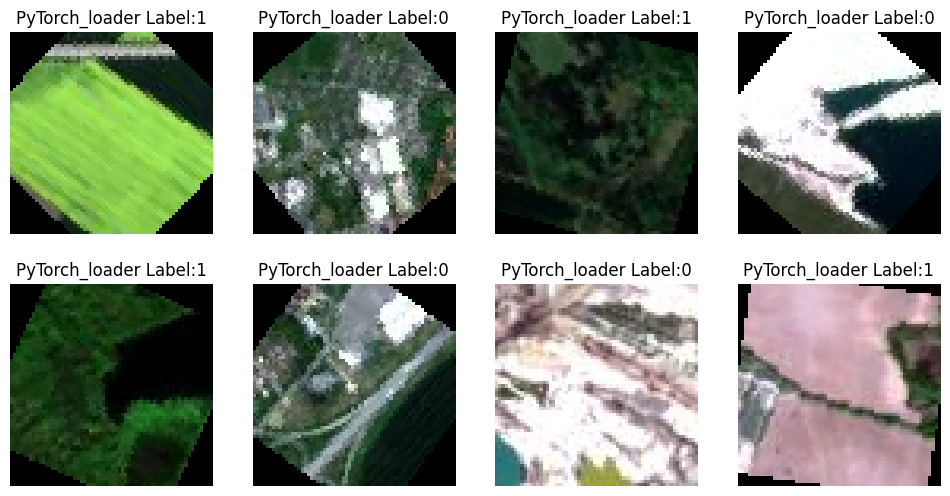

In [10]:
plt.figure(figsize = (12, 6))
for i in range(BATCH_SIZE):
    ax = plt.subplot(2, 4, i + 1)
    imshow(images_inbuilt[i])
    plt.title(f"PyTorch_loader Label:{labels_inbuilt[i].item()}")
    plt.axis("off")    

| Feature                  | Custom `Dataset`                                       | In-built `ImageFolder`     |
|--------------------------|-------------------------------------------------------------|-------------------------------------------------------------|
| **Ease of use**          | Low. It requires writing a custom class with three specific methods. | High. It requires only a single, intuitive class instantiation. |
| **Code complexity**      | High. You manually manage file paths, labels, and the loading logic inside `__getitem__`. | Low. The class handles all path and label discovery automatically.          |
| **Flexibility**          | Very high. It is essential for non-standard directory structures, loading labels from a CSV/JSON, or complex loading logic (for example, from a database). | Moderate. It strictly requires the `root/class/image.ext` directory structure. |
| **Performance**          | Potentially high. Performance depends on the efficiency of your `__getitem__` method. When wrapped in a `DataLoader` with `num_workers`, it can be highly performant. | High. `ImageFolder` is optimized and, when wrapped in a `DataLoader`, provides excellent performance out-of-the-box. |
| **Recommended for**      | It is recommended for complex, non-standard datasets or when you need fine-grained control over every aspect of data loading. | It is recommended for almost all standard image classification tasks.        |
